シンプルな**Grid World（4×4の迷路環境）**を使って、エージェントがゴールにたどり着くように学習します。

Dyna-Qは「経験（Q学習）」と「モデルベースのシミュレーション（計画）」を組み合わせた手法です。

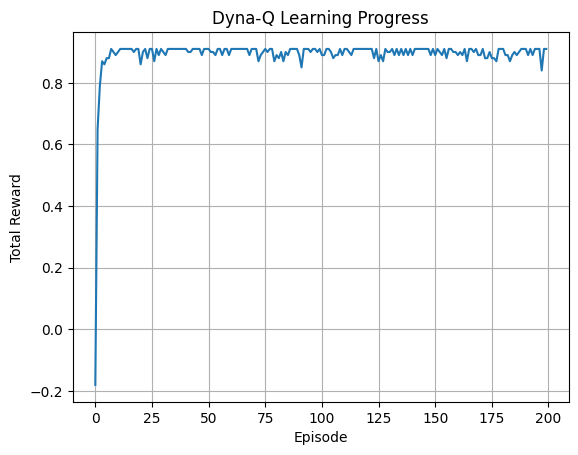

In [1]:
# ============================================
# 📘 Dyna-Q implementation example (GridWorld)
# Google Colab ready
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random

# -----------------------------
# 環境定義（GridWorld 4x4）
# -----------------------------
class GridWorld:
    def __init__(self, size=4):
        self.size = size
        self.start = (0, 0)
        self.goal = (size - 1, size - 1)
        self.state = self.start
        self.actions = ["up", "down", "left", "right"]

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        x, y = self.state
        if action == "up":
            x = max(0, x - 1)
        elif action == "down":
            x = min(self.size - 1, x + 1)
        elif action == "left":
            y = max(0, y - 1)
        elif action == "right":
            y = min(self.size - 1, y + 1)

        new_state = (x, y)
        reward = 1.0 if new_state == self.goal else -0.01
        done = new_state == self.goal
        self.state = new_state
        return new_state, reward, done

# -----------------------------
# Dyna-Q エージェント
# -----------------------------
class DynaQAgent:
    def __init__(self, actions, alpha=0.1, gamma=0.95, epsilon=0.1, planning_steps=10):
        self.Q = defaultdict(lambda: np.zeros(len(actions)))
        self.model = {}  # (s, a) -> (s', r)
        self.actions = actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.planning_steps = planning_steps

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.choice(len(self.actions))
        return np.argmax(self.Q[state])

    def learn(self, state, action, reward, next_state, done):
        # Q-learning更新
        best_next = np.max(self.Q[next_state])
        td_target = reward + self.gamma * best_next * (not done)
        self.Q[state][action] += self.alpha * (td_target - self.Q[state][action])

        # モデルを更新
        self.model[(state, action)] = (next_state, reward)

        # 計画（モデルベースの更新）
        for _ in range(self.planning_steps):
            (s, a), (s_next, r) = random.choice(list(self.model.items()))
            best_next2 = np.max(self.Q[s_next])
            td_target2 = r + self.gamma * best_next2
            self.Q[s][a] += self.alpha * (td_target2 - self.Q[s][a])

# -----------------------------
# 学習ループ
# -----------------------------
env = GridWorld(size=6)
agent = DynaQAgent(env.actions, planning_steps=20)

episodes = 200
rewards = []

for ep in range(episodes):
    state = env.reset()
    total_reward = 0
    done = False
    while not done:
        action_idx = agent.choose_action(state)
        action = env.actions[action_idx]
        next_state, reward, done = env.step(action)
        agent.learn(state, action_idx, reward, next_state, done)
        state = next_state
        total_reward += reward
    rewards.append(total_reward)

# -----------------------------
# 結果表示
# -----------------------------
plt.plot(rewards)
plt.title("Dyna-Q Learning Progress")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()


初期：報酬（青線）は低い（ゴールまでたどり着けない）

学習後：報酬が安定して上昇（効率よくゴールへ）